In [77]:
# Import libraries
import torch
import torch.nn as nn
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from pathlib import Path
from tqdm.auto import tqdm

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.14.0+cpu


In [91]:
# Create some parameters
device = "cuda" if torch.cuda.is_available() else "cpu"
TEST = 0.2
LR = 0.005
RANDOM_SEED = 42
EPOCHS = 2000

In [79]:
# Check, Clean and Prepare the data
row_data = pd.read_csv("row_data.csv", na_values=['', ' ', 'N/A', 'nan', 'null'])
print(f"Data Length: {len(row_data)} | Count of Null and empty data: {row_data.isnull().sum()}")

# Clean the data
row_data = row_data.dropna()

# Turn string data into numbers
print(f"""
Print all string data: \n
{row_data["Weather"].unique()}\n
{row_data["Traffic_Level"].unique()}\n
{row_data["Time_of_Day"].unique()}\n
{row_data["Vehicle_Type"].unique()}\n
""")

row_data["Traffic_Level"] = row_data["Traffic_Level"].map({'Low': 0, "Medium": 1, 'High': 2}) # Turn "Traffic_Level" data into Nominal data
row_data = pd.get_dummies(row_data, columns=['Weather','Time_of_Day' , 'Vehicle_Type'], dtype=int) # Turn "Weather", "Time_Of_Day", "Vehicle_Type" data into one hot Encoding

# Order the data
row_data = row_data[['Order_ID', 'Distance_km', 'Traffic_Level', 'Preparation_Time_min', 'Courier_Experience_yrs',
                     'Weather_Clear', 'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
                     'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
                     'Vehicle_Type_Bike', 'Vehicle_Type_Car', 'Vehicle_Type_Scooter', 'Delivery_Time_min']]

row_data.to_csv("data.csv", index=0) # Turn the clean data into new csvfile "data.csv"

Data Length: 1000 | Count of Null and empty data: Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Print all string data: 

<StringArray>
['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy']
Length: 5, dtype: str

<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

<StringArray>
['Afternoon', 'Evening', 'Night', 'Morning']
Length: 4, dtype: str

<StringArray>
['Scooter', 'Bike', 'Car']
Length: 3, dtype: str




In [80]:
# Import USA_Housing.csv file and take the important data from it then turn it into numpy's array
row_data = pd.read_csv("data.csv")
data = row_data.iloc[:, 1:-1].to_numpy()
labels = row_data.iloc[:, -1].to_numpy()

# Split the data into training and test data
train_data, test_data, train_label, test_label = train_test_split(
    data,
    labels,
    test_size=TEST,
    random_state=RANDOM_SEED
)

# turn data into tensors
train_data = torch.tensor(train_data, dtype=torch.float32)
train_label = torch.tensor(train_label, dtype=torch.float32)
test_data = torch.tensor(test_data, dtype=torch.float32)
test_label = torch.tensor(test_label, dtype=torch.float32)


In [86]:
print(train_data.shape)
print(train_label.shape)
print(test_data.shape)
print(test_label.shape)

torch.Size([706, 16])
torch.Size([706])
torch.Size([177, 16])
torch.Size([177])


In [81]:
# Create some plot helpful functions
def pairplot(data):
    sns.pairplot(data)
    plt.show()

def plot_data(test_labels,
              Predictions=None):
    plt.style.use("dark_background")
    plt.figure(figsize=(7, 7))

    plt.scatter(test_labels, test_labels, c="g", s=4, label="Test label")

    if Predictions is not None:
        plt.scatter(Predictions, test_labels, c="r", s=4, label="Predictions")

    plt.legend(fontsize=14)
    plt.xlabel("Data")
    plt.ylabel("Label")
    plt.show()

def plot_loss(train_loss: list,
              test_loss: list,
              epochs: list):
    plt.figure(figsize=(7, 7))
    plt.style.use("dark_background")

    plt.plot(epochs, np.array(train_loss), color="orange", label="Train loss")
    plt.plot(epochs, np.array(test_loss), color="g", label="Test loss")

    plt.legend(fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.show()

In [82]:
# Create the model class
class Delivery_timesModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.Linear = nn.Sequential(
            nn.Linear(16, 30),
            nn.ReLU(),
            nn.Linear(30, 30),
            nn.ReLU(),
            nn.Linear(30, 1)
        )

    def forward(self, x):
        return self.Linear(x)

# Create the model
torch.manual_seed(RANDOM_SEED)
model = Delivery_timesModel()

In [83]:
# Create loss function and optimizer
loss = nn.L1Loss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=LR)

In [92]:
# Create the Training and Testing function
def train_test_func(model:torch.nn.Module,
                    epochs: int,
                    loss_fn: torch.nn.L1Loss,
                    optimizer: torch.optim.Optimizer):
    epochs_list = []
    train_loss_values = []
    test_loss_values = []

    for epoch in tqdm(range(epochs)):
        model.train()

        train_pred = model(train_data)
        train_loss = loss_fn(train_pred, train_label)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        model.eval() 
        with torch.inference_mode():
            test_pred = model(test_data)
            test_loss = loss_fn(test_pred, test_label)

        epochs_list.append(epoch)
        train_loss_values.append(train_loss.item())
        test_loss_values.append(test_loss.item())

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Train loss: {train_loss} | Test loss: {test_loss.item()}", end=" \n")

    return epochs_list, train_loss_values, test_loss_values

# Train the data
epochs_list, train_loss_list, test_loss_list = train_test_func(model=model, epochs=EPOCHS, loss_fn=loss, optimizer=optimizer)

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 17.593355178833008 | Test loss: 17.135501861572266 
Epoch: 10 | Train loss: 17.581335067749023 | Test loss: 17.65255355834961 
Epoch: 20 | Train loss: 17.569604873657227 | Test loss: 17.163646697998047 
Epoch: 30 | Train loss: 17.62622833251953 | Test loss: 17.485361099243164 
Epoch: 40 | Train loss: 17.567228317260742 | Test loss: 17.380504608154297 
Epoch: 50 | Train loss: 17.569040298461914 | Test loss: 17.327701568603516 
Epoch: 60 | Train loss: 17.5642147064209 | Test loss: 17.424789428710938 
Epoch: 70 | Train loss: 17.563716888427734 | Test loss: 17.626943588256836 
Epoch: 80 | Train loss: 17.586013793945312 | Test loss: 17.20498275756836 
Epoch: 90 | Train loss: 17.584026336669922 | Test loss: 17.496540069580078 
Epoch: 100 | Train loss: 17.59044647216797 | Test loss: 17.44195556640625 
Epoch: 110 | Train loss: 17.602500915527344 | Test loss: 17.333969116210938 
Epoch: 120 | Train loss: 17.567800521850586 | Test loss: 17.38565444946289 
Epoch: 130 | Train

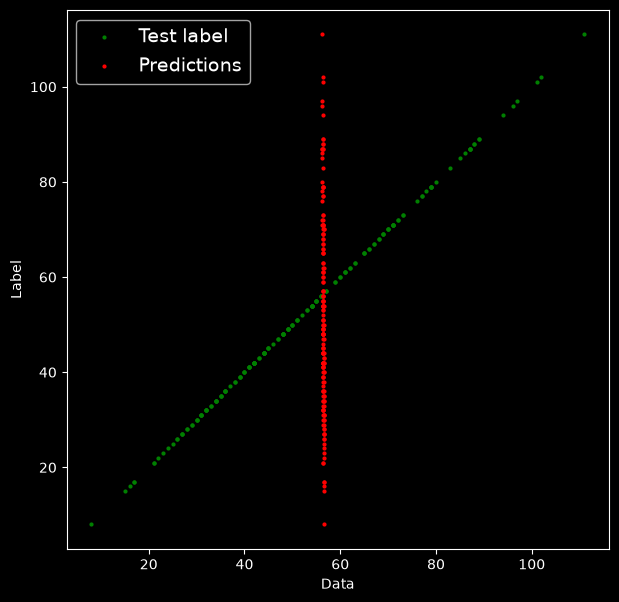

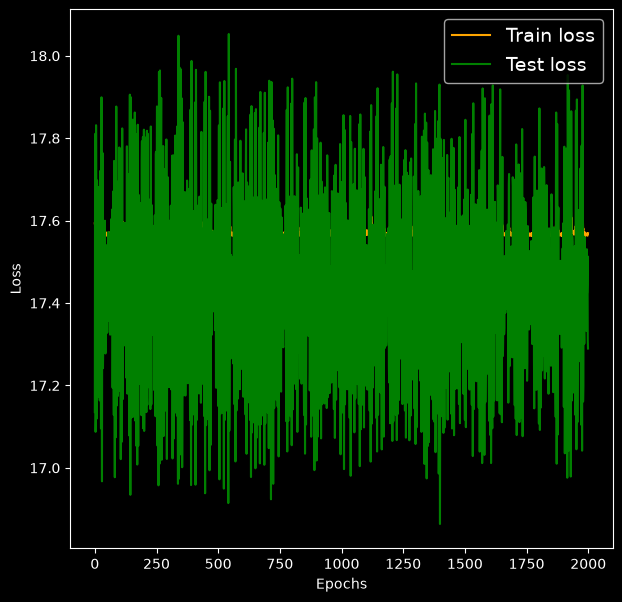

In [93]:
# Plot all needed data
plot_data(test_label, model(test_data).cpu().detach().numpy())
plot_loss(epochs=epochs_list, test_loss=test_loss_list, train_loss=train_loss_list)